In [1]:
!pip install opencv-python matplotlib scikit-image tqdm

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

In [3]:
!ls -lah /content

total 61M
drwxr-xr-x 1 root root 4.0K Jul 14 01:37  .
drwxr-xr-x 1 root root 4.0K Jul 14 01:31  ..
drwxr-xr-x 4 root root 4.0K Jun  4 13:32  .config
-rw-r--r-- 1 root root 819K Jul 14 01:37  Gold_Standard_Semantic_Segmentation.zip
-rw-r--r-- 1 root root  60M Jul 14 01:38 'Original ROI images.zip'
drwxr-xr-x 1 root root 4.0K Jun  4 13:32  sample_data


In [4]:
zip_files = glob("/content/*.zip")

for arquivo in zip_files:
    print(arquivo)

/content/Gold_Standard_Semantic_Segmentation.zip
/content/Original ROI images.zip


In [5]:
!unzip -q "/content/Original ROI images.zip" -d "/content/imagens"
!unzip -q "/content/Gold_Standard_Semantic_Segmentation.zip" -d "/content/mascaras"

In [6]:
!find /content/imagens -maxdepth 3 -type d
!find /content/mascaras -maxdepth 3 -type d

/content/imagens
/content/imagens/Original ROI images
/content/imagens/Original ROI images/severe
/content/imagens/Original ROI images/healthy
/content/mascaras
/content/mascaras/Gold_Standard_Semantic_Segmentation
/content/mascaras/Gold_Standard_Semantic_Segmentation/severe
/content/mascaras/Gold_Standard_Semantic_Segmentation/healthy


# Preparação e exploração dos dados


In [14]:
image_paths = sorted(
    glob("/content/imagens/Original ROI images/healthy/*.tif")
)

mask_paths = sorted(
    glob("/content/mascaras/Gold_Standard_Semantic_Segmentation/healthy/*.png")
)

print(f"Quantidade de imagens : {len(image_paths)}")
print(f"Quantidade de máscaras: {len(mask_paths)}")

Quantidade de imagens : 114
Quantidade de máscaras: 114


Let's check the contents of the `healthy` directory to see what kind of files are there. This will help us correct the `glob` pattern if needed.

In [15]:
!ls -l "/content/imagens/Original ROI images/healthy/"

total 38304
-rw-r--r-- 1 root root 340790 Feb 18  2023 healthy-01-roi1.tif
-rw-r--r-- 1 root root 340752 Feb 18  2023 healthy-01-roi2.tif
-rw-r--r-- 1 root root 340790 Feb 18  2023 healthy-01-roi3.tif
-rw-r--r-- 1 root root 340792 Feb 18  2023 healthy-01-roi4.tif
-rw-r--r-- 1 root root 340778 Feb 18  2023 healthy-01-roi5.tif
-rw-r--r-- 1 root root 340790 Feb 18  2023 healthy-02-roi1.tif
-rw-r--r-- 1 root root 340790 Feb 18  2023 healthy-02-roi2.tif
-rw-r--r-- 1 root root 340782 Feb 18  2023 healthy-02-roi3.tif
-rw-r--r-- 1 root root 340716 Feb 18  2023 healthy-02-roi4.tif
-rw-r--r-- 1 root root 340790 Feb 18  2023 healthy-02-roi5.tif
-rw-r--r-- 1 root root 340790 Feb 18  2023 healthy-03-roi1.tif
-rw-r--r-- 1 root root 340780 Feb 18  2023 healthy-03-roi2.tif
-rw-r--r-- 1 root root 340758 Feb 18  2023 healthy-03-roi3.tif
-rw-r--r-- 1 root root 340790 Feb 18  2023 healthy-03-roi4.tif
-rw-r--r-- 1 root root 340792 Feb 18  2023 healthy-04-roi1.tif
-rw-r--r-- 1 root root 340784 Feb 18  2023 

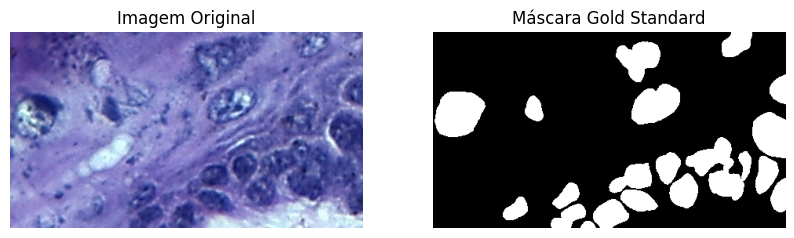

In [16]:

imagem = cv2.imread(image_paths[0])
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

mascara = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imagem)
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mascara, cmap="gray")
plt.title("Máscara Gold Standard")
plt.axis("off")

plt.show()